# ニューラルネットワークの基礎：`nn.Sequential` で理解する

このノートブックでは，PyTorch の `nn.Sequential` を題材にして，ニューラルネットワークが「微分可能な関数を順番につないだもの」であることを確認する。
最後に Iris dataset を使い，訓練データ・バリデーションデータ・テストデータに分けて，実際に多クラス分類を学習する。

## このノート全体の流れ

このノートでは，次の順番で読むと理解しやすい。

1. 入力データが `nn.Sequential` の層を順番に通ることを確認する。
2. `Linear`，活性化関数，損失関数がそれぞれ何を計算しているかを確認する。
3. 損失を小さくするために，勾配降下法とバックプロパゲーションでパラメータを更新する流れを確認する。
4. Iris dataset を使って，データ分割，標準化，ミニバッチ，学習，評価までを一通り実行する。

## このノートでの読み方

- 数式は，プログラムが何を計算しているかを確認するための地図として読む。
- `Tensor` は，まずは NumPy 配列に近い「数値の入れ物」と考える。
- `勾配` は，「損失を減らすには値をどちらへ動かせばよいか」を表す手がかりである。
- すべての PyTorch 命令を覚える必要はない。`Linear`，損失，`backward`，`step` の役割を押さえる。

## 到達目標

- `nn.Linear` が行列積とバイアス加算をしていることを説明できる。
- 活性化関数を挟む理由と，代表的な活性化関数の形を説明できる。
- 損失関数が「パラメータの良さ」を数値化する関数であることを説明できる。
- 勾配降下法とバックプロパゲーションの役割を区別できる。
- Iris dataset を使った学習で，train / validation / test，ミニバッチ，学習率，汎化性能を説明できる。


## 準備

このノートブックでは，PyTorch，NumPy，matplotlib，scikit-learn を使う。
乱数の影響で結果が大きく変わらないように，最初にシードを固定しておく。


In [1]:
from collections.abc import Callable

import matplotlib.pyplot as plt
import matplotlib_fontja
import numpy as np
import pandas as pd
import torch
from sklearn.datasets import load_iris
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F

plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True

torch.manual_seed(0)
np.random.seed(0)


# 1. ニューラルネットワークの仕組み

ニューラルネットワークは，入力された数値を，いくつかの層で順番に変換して，最後に予測結果を出すモデルである。
Iris dataset では，1つの花を4個の数値で表す。

- がく片の長さ
- がく片の幅
- 花びらの長さ
- 花びらの幅

この4個の数値を入力として受け取り，「setosa / versicolor / virginica のどれらしいか」という3個の値を出す。

PyTorch では，複数データをまとめた表を `Tensor` として扱う。Iris の入力は「データ数 $N$，特徴量数 4」の形なので，shape は $(N, 4)$ になる。1個の花だけをモデルに入れる場合も，shape は `(4,)` ではなく `(1, 4)` のように「1行4列」として扱うと考えるとよい。
PyTorch では，`nn.Sequential` を使うと「層を上から順番に通す」モデルを簡潔に書ける。

例えば，4個の特徴量を受け取り，5個の中間表現に変換し，最後に3クラスの確率を出す説明用モデルは次のように書ける。


In [2]:
model = nn.Sequential(
    nn.Linear(4, 5),
    nn.ReLU(),
    nn.Linear(5, 3),
    nn.Softmax(dim=1),
)

print(model)


Sequential(
  (0): Linear(in_features=4, out_features=5, bias=True)
  (1): ReLU()
  (2): Linear(in_features=5, out_features=3, bias=True)
  (3): Softmax(dim=1)
)


### `nn.Sequential` の読み方

`nn.Sequential` は，書いた順番に層を実行する入れ物である。上の例では，入力は次の順に変換される。

1. `nn.Linear(4, 5)`：4個の特徴量を5個の数値に変換する。
2. `nn.ReLU()`：負の値を0にし，非線形な変換を加える。
3. `nn.Linear(5, 3)`：5個の中間表現を3クラス分のスコアに変換する。
4. `nn.Softmax(dim=1)`：3クラス分のスコアを，合計が1になる確率に変換する。

`Softmax` に入る前の3個の値は，まだ確率ではない。このような「確率に変換する前の点数」をロジットと呼ぶ。
`Softmax` は，ロジットが大きいクラスほど大きな確率になるように変換する関数である。
`dim=1` は，ミニバッチの各行について，列方向つまりクラス方向に Softmax をかけるという意味である。

ただし，これは説明用の書き方である。実際に `nn.CrossEntropyLoss` を使って分類モデルを訓練するときは，モデルの最後に `Softmax` を入れない。
`CrossEntropyLoss` の中に Softmax 相当の計算が含まれているため，学習用モデルはロジットをそのまま出す形にする。


## `Linear` レイヤの中でやっていること

`nn.Linear(in_features, out_features)` は，次の計算をしている。

$$
y = x W^\top + b
$$

ここで，$x$ は入力，$W$ は重み行列，$b$ はバイアス，$y$ は次の層へ渡す値である。
`Linear` は名前の通り，入力を線形変換する層である。重み $W$ とバイアス $b$ は学習によって更新されるパラメータである。


次の図では，単一サンプルを列ベクトルとして見たときの全結合層の計算を表している．
式は出力を左辺に置いて，$y = W \cdot x + b$ と読む．
四角形の横幅は列数，縦幅は行数を表す．同じ shape 成分は，同じ長さの辺で表している．

![全結合層の計算](../assets/fully_connected_layer_calculation.svg)

この図の編集用ファイルは `assets/fully_connected_layer_calculation.drawio` である．
PyTorch の `nn.Linear` では，重みは `(out_features, in_features)` の形で保持されるため，ミニバッチ入力では `X @ W.T + b` と計算される．

In [3]:
linear = nn.Linear(in_features=4, out_features=3)

x = torch.tensor([[5.1, 3.5, 1.4, 0.2]], dtype=torch.float32)
y_layer = linear(x)
y_manual = x @ linear.weight.T + linear.bias

print("weight shape:", tuple(linear.weight.shape))
print("bias shape:", tuple(linear.bias.shape))
print("Linear layer output:", y_layer)
print("Manual calculation:", y_manual)
print("same result:", torch.allclose(y_layer, y_manual))


weight shape: (3, 4)
bias shape: (3,)
Linear layer output: tensor([[-4.2376,  0.8509,  3.0035]], grad_fn=<AddmmBackward0>)
Manual calculation: tensor([[-4.2376,  0.8509,  3.0035]], grad_fn=<AddBackward0>)
same result: True


上の例では，入力は4個の数値，出力は3個の数値である。
そのため，`weight` の形は `(3, 4)` になる。これは「3個の出力それぞれが，4個の入力を重み付きで足し合わせる」ことを表している。

1つ目の出力だけを書くと，次のようになる。

$$
y_1 = w_{11}x_1 + w_{12}x_2 + w_{13}x_3 + w_{14}x_4 + b_1
$$

同じ計算を $y_2, y_3$ についても行うので，4個の入力から3個の出力が作られる。

## 線形変換だけでは表現力が足りない

`Linear` は，入力を重み付きで足し合わせる層である。
しかし，`Linear` だけを何回重ねても，全体としては1つの線形変換にまとめられる。
つまり，直線的な関係しか表しにくい。

実際のデータでは，「この特徴量が大きければ必ずこのクラス」と単純に決まらないことが多い。
そこで，`Linear` の間に非線形な活性化関数を入れて，関係を曲げられるようにする。

## 活性化関数の役割

ここでは代表的な活性化関数として，Sigmoid，ReLU，Tanh の3つを見る。
グラフを見ると，入力 $x$ に対して出力の形がどのように変わるかを確認できる。

`nn.Sequential` では，`Linear` と活性化関数を交互に並べることが多い。`Linear` が数値を混ぜ合わせ，活性化関数が非線形な曲がりを加える，という役割分担で見ると読みやすい。


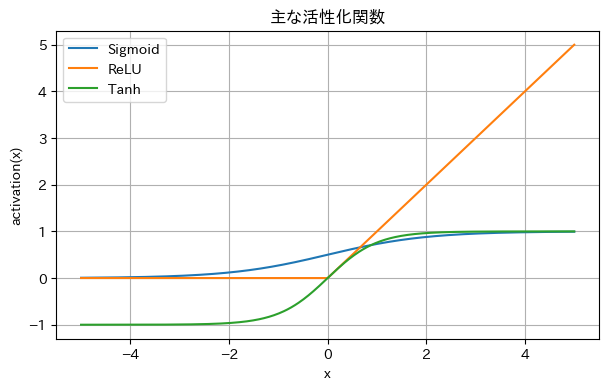

In [4]:
xs = torch.linspace(-5, 5, 400)
activation_functions: dict[str, Callable[[torch.Tensor], torch.Tensor]] = {
    "Sigmoid": F.sigmoid,
    "ReLU": F.relu,
    "Tanh": F.tanh,
}

fig, ax = plt.subplots()
for name, fn in activation_functions.items():
    ax.plot(xs.numpy(), fn(xs).numpy(), label=name)
ax.set_xlabel("x")
ax.set_ylabel("activation(x)")
ax.set_title("主な活性化関数")
ax.legend()
plt.show()


次の表示では，Jupyter Book 上でも操作できるように，通常のHTMLビューアを `iframe` で埋め込む。
ドロップダウンで活性化関数を切り替えると，グラフと forward / backward の式が一緒に変わる。

<p><a href="https://raw.githack.com/rsimd/NITIC-IntroductionToDeepLearning/main/demos/activation_functions_viewer.html?v=20260520" target="_blank" rel="noopener">別タブで活性化関数ビューアを開く</a></p>

<iframe
  src="https://raw.githack.com/rsimd/NITIC-IntroductionToDeepLearning/main/demos/activation_functions_viewer.html?v=20260520"
  width="100%"
  height="560"
  style="border: 1px solid #d7dde5; border-radius: 8px;"
  loading="lazy"
  title="Activation Functions Viewer"
></iframe>



## 微分可能な関数をつないでいる

学習では「損失を小さくするには，パラメータをどちらに動かせばよいか」を知る必要がある。
この手がかりが勾配である。
勾配を計算するため，ニューラルネットワークを構成する計算は基本的に微分可能な関数で作る。

`requires_grad=True` を付けた Tensor は，PyTorch が計算の道筋を記録する。
その後で `backward()` を呼ぶと，入力やパラメータに対する勾配が計算される。

※ 厳密には ReLU は $x=0$ で微分できないが，それ以外の点では微分できる。PyTorch のような深層学習ライブラリでは，$x=0$ のような点にも実用上の勾配を定義して計算を進める。


In [5]:
x = torch.tensor([[1.0, -2.0, 0.5, 3.0]], requires_grad=True)
small_model = nn.Sequential(
    nn.Linear(4, 3),
    nn.Tanh(),
    nn.Linear(3, 1),
)

output = small_model(x)
output.backward()

print("output:", output.item())
print("d output / d x:", x.grad)
for name, parameter in small_model.named_parameters():
    print(name, "grad shape:", tuple(parameter.grad.shape))


output: 0.4614245593547821
d output / d x: tensor([[-0.2082, -0.0473,  0.1834,  0.0969]])
0.weight grad shape: (3, 4)
0.bias grad shape: (3,)
2.weight grad shape: (1, 3)
2.bias grad shape: (1,)


# 2. 損失関数

損失関数は，モデルの予測が正解からどれくらい外れているかを数値にする関数である。
教師あり学習では，入力データだけでなく正解ラベルも使う。モデルの出力と正解ラベルを損失関数に入れると，「どれくらい外れたか」が1つの数値として返ってくる。
学習では，損失が小さくなるようにパラメータを更新する。

$$
\text{損失が小さい} \quad \Longleftrightarrow \quad \text{そのデータに対して良いパラメータである}
$$

ただし，訓練データだけで損失が小さいことと，未知データでもよく当たることは同じではない。この違いは最後の「汎化性能」で扱う。


## 二乗誤差

回帰問題では，予測値 $\hat{y}$ と正解値 $y$ の差を二乗した二乗誤差がよく使われる。
平均二乗誤差は次の式で表される。

$$
\mathrm{MSE}(\hat{y}, y) = \frac{1}{N} \sum_{i=1}^{N} (\hat{y}_i - y_i)^2
$$


In [6]:
y_true = torch.tensor([1.0, 2.0, 3.0])
y_pred = torch.tensor([1.2, 1.8, 2.5], requires_grad=True)

mse_loss = nn.MSELoss()(y_pred, y_true)
mse_loss.backward()

print("MSE:", mse_loss.item())
print("d MSE / d prediction:", y_pred.grad)


MSE: 0.11000001430511475
d MSE / d prediction: tensor([ 0.1333, -0.1333, -0.3333])


## クロスエントロピー

分類問題では，クロスエントロピーがよく使われる。
多クラス分類で，正解クラスが $c$，モデルが各クラスに割り当てた確率が $p_1, p_2, \ldots, p_K$ のとき，1データのクロスエントロピーは次の式で表される。

$$
\mathrm{CE}(p, c) = -\log p_c
$$

ここで，$p_c$ は「正解クラスに割り当てた確率」である。
$\log$ は自然対数であり，$p_c$ が1に近いほど $-\log p_c$ は0に近くなる。
反対に，正解クラスの確率が小さいと，損失は大きくなる。

PyTorch の `nn.CrossEntropyLoss` は，モデルの出力を確率ではなくロジットとして受け取る。
ロジットは，確率に変換する前の「各クラスの点数」と考えればよい。
内部で `Softmax` と `-log` をまとめて計算するため，モデルの最後に `Softmax` を置かないのが一般的である。


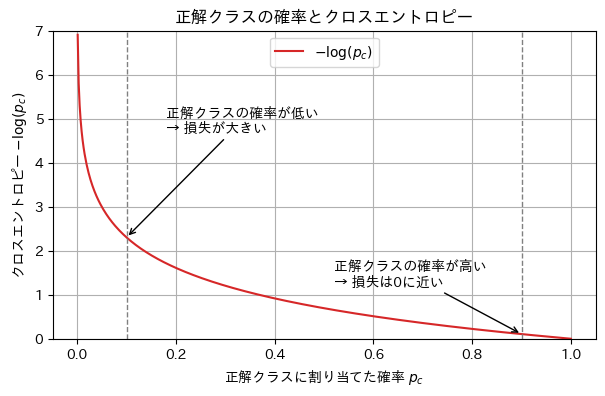

In [7]:
p_correct = np.linspace(0.001, 1.0, 500)
cross_entropy = -np.log(p_correct)

fig, ax = plt.subplots()
ax.plot(p_correct, cross_entropy, color="tab:red", label=r"$-\log(p_c)$")
ax.axvline(0.1, color="gray", linestyle="--", linewidth=1)
ax.axvline(0.9, color="gray", linestyle="--", linewidth=1)
ax.annotate("正解クラスの確率が低い\n→ 損失が大きい", xy=(0.1, -np.log(0.1)), xytext=(0.18, 4.7), arrowprops={"arrowstyle": "->"})
ax.annotate("正解クラスの確率が高い\n→ 損失は0に近い", xy=(0.9, -np.log(0.9)), xytext=(0.52, 1.2), arrowprops={"arrowstyle": "->"})
ax.set_xlabel("正解クラスに割り当てた確率 $p_c$")
ax.set_ylabel(r"クロスエントロピー $-\log(p_c)$")
ax.set_title("正解クラスの確率とクロスエントロピー")
ax.set_ylim(0, 7)
ax.legend()
plt.show()


In [8]:
logits = torch.tensor(
    [[2.0, 0.5, -1.0], [0.1, 1.5, 0.3]],
    requires_grad=True,
)
target = torch.tensor([0, 2])

ce_loss = nn.CrossEntropyLoss()(logits, target)
ce_loss.backward()

probabilities = torch.softmax(logits.detach(), dim=1)
print("probabilities:\n", probabilities)
print("Cross entropy:", ce_loss.item())
print("d CE / d logits:\n", logits.grad)


probabilities:
 tensor([[0.7856, 0.1753, 0.0391],
        [0.1593, 0.6461, 0.1946]])
Cross entropy: 0.9390701055526733
d CE / d logits:
 tensor([[-0.1072,  0.0876,  0.0196],
        [ 0.0797,  0.3230, -0.4027]])


In [9]:
first_probability = probabilities[0, target[0]]
first_ce = -torch.log(first_probability)

print("first data probabilities:", probabilities[0])
print("target class:", int(target[0]))
print("probability of target class:", float(first_probability))
print("-log(probability):", float(first_ce))

first data probabilities: tensor([0.7856, 0.1753, 0.0391])
target class: 0
probability of target class: 0.785597026348114
-log(probability): 0.24131131172180176


## Forward の流れをアニメーションで確認

次のアニメーションでは，入力から各層の出力，Softmax，損失までの forward 計算を shape と一緒に確認できる．
`Linear`，活性化関数，損失関数が順番につながっていることに注目する．

<p><a href="https://raw.githack.com/rsimd/NITIC-IntroductionToDeepLearning/main/demos/forward_loss_animation.html" target="_blank" rel="noopener">別タブで forward アニメーションを開く</a></p>

<iframe
  src="https://raw.githack.com/rsimd/NITIC-IntroductionToDeepLearning/main/demos/forward_loss_animation.html?v=20260520"
  width="100%"
  height="900"
  style="border: 1px solid #d7dde5; border-radius: 8px;"
  loading="lazy"
  title="Forward and loss animation"
></iframe>

# 3. パラメータ更新方法

ニューラルネットワークの学習では，損失関数 $L$ を小さくするようにパラメータ $\theta$（各レイヤーの $W$ や $b$ のこと）を更新する。
最も基本的な考え方が勾配降下法である。

$$
\theta \leftarrow \theta - \eta \frac{\partial L}{\partial \theta}
$$

ここで，$\eta$ は学習率である。学習率は1回の更新でどれくらい大きくパラメータを動かすかを決める値である。

`optimizer` は，この更新式を実際に適用するための PyTorch の部品である。`torch.optim.SGD` は，勾配降下法に基づいてパラメータを更新する代表的な optimizer である。


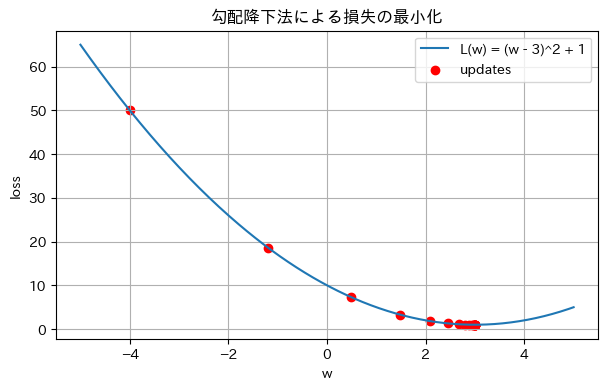

final w: 2.999744176864624


In [10]:
def objective(w: torch.Tensor) -> torch.Tensor:
    return (w - 3) ** 2 + 1


w = torch.tensor(-4.0, requires_grad=True)
lr = 0.2
history_gd: list[tuple[float, float]] = [] # (w, loss) pairs

for step in range(20):
    loss = objective(w)
    loss.backward()

    with torch.no_grad():
        history_gd.append((float(w), float(loss)))
        w -= lr * w.grad
        w.grad.zero_()

ws = np.linspace(-5, 5, 300)
losses = (ws - 3) ** 2 + 1

fig, ax = plt.subplots()
ax.plot(ws, losses, label="L(w) = (w - 3)^2 + 1")
ax.scatter([h[0] for h in history_gd], [h[1] for h in history_gd], color="red", label="updates")
ax.set_xlabel("w")
ax.set_ylabel("loss")
ax.set_title("勾配降下法による損失の最小化")
ax.legend()
plt.show()

print("final w:", float(w.detach()))


## optimizer の違い

`optimizer` は，損失を小さくするために，パラメータ $\theta$ をどの方向へどれくらい動かすかを決める部品である。
PyTorch では `torch.optim` の中に多くの optimizer が用意されている。
ここでは代表例として，`SGD`，`SGD + momentum`，`Adam` の3つを比べる。

- `SGD`：現在の勾配だけを見て，損失が小さくなる方向へ動く。単純で分かりやすいが，谷が細長い形の損失では左右に揺れながら進むことがある。
- `SGD + momentum`：過去の更新方向を「勢い」として少し残しながら動く。同じ方向に勾配が続くと加速し，細長い谷での揺れを小さくしやすい。
- `Adam`：勾配の平均と，勾配の二乗の平均を使って，パラメータごとに動く量を調整する。深層学習では最初に試す optimizer としてよく使われる。

次のアニメーションでは，2つのパラメータを持つ簡単な損失関数を最小化する様子を見る。
赤い星が損失の最小値であり，各線は optimizer がパラメータをどのように動かしたかを表している。


In [11]:
from IPython.display import HTML
from matplotlib.animation import FuncAnimation


def optimizer_objective(params: torch.Tensor) -> torch.Tensor:
    x, y = params[0], params[1]
    return 0.08 * (x - 2.5) ** 2 + 0.8 * (y + 1.0) ** 2


def trace_optimizer(make_optimizer, steps: int = 45) -> tuple[np.ndarray, list[float]]:
    params = torch.nn.Parameter(torch.tensor([-4.0, 3.0]))
    optimizer = make_optimizer([params])
    path: list[np.ndarray] = []
    loss_history: list[float] = []

    for _ in range(steps):
        optimizer.zero_grad()
        loss = optimizer_objective(params)
        loss.backward()
        path.append(params.detach().numpy().copy())
        loss_history.append(float(loss.detach()))
        optimizer.step()

    path.append(params.detach().numpy().copy())
    loss_history.append(float(optimizer_objective(params).detach()))
    return np.array(path), loss_history


optimizer_traces = {
    "SGD": trace_optimizer(lambda p: torch.optim.SGD(p, lr=0.18)),
    "SGD + momentum": trace_optimizer(lambda p: torch.optim.SGD(p, lr=0.12, momentum=0.85)),
    "Adam": trace_optimizer(lambda p: torch.optim.Adam(p, lr=0.22)),
}

x_grid = np.linspace(-4.5, 3.5, 160)
y_grid = np.linspace(-3.0, 3.5, 160)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid)
Z_grid = 0.08 * (X_grid - 2.5) ** 2 + 0.8 * (Y_grid + 1.0) ** 2

fig, ax = plt.subplots(figsize=(7, 5))
ax.contour(X_grid, Y_grid, Z_grid, levels=18, cmap="Greys", alpha=0.7)
ax.scatter([2.5], [-1.0], marker="*", s=180, color="red", label="minimum")

colors = {
    "SGD": "tab:blue",
    "SGD + momentum": "tab:orange",
    "Adam": "tab:green",
}
lines = {}
points = {}
for name, (path_points, _) in optimizer_traces.items():
    (line,) = ax.plot([], [], color=colors[name], linewidth=2, label=name)
    (point,) = ax.plot([], [], "o", color=colors[name], markersize=6)
    lines[name] = line
    points[name] = point

ax.set_xlim(-4.5, 3.5)
ax.set_ylim(-3.0, 3.5)
ax.set_xlabel("parameter 1")
ax.set_ylabel("parameter 2")
ax.legend(loc="upper right")

max_frames = max(len(path_points) for path_points, _ in optimizer_traces.values())


def update_optimizer_animation(frame: int):
    artists = []
    for name, (path_points, _) in optimizer_traces.items():
        last_index = min(frame, len(path_points) - 1)
        visible_path = path_points[: last_index + 1]
        lines[name].set_data(visible_path[:, 0], visible_path[:, 1])
        points[name].set_data([path_points[last_index, 0]], [path_points[last_index, 1]])
        artists.extend([lines[name], points[name]])
    ax.set_title(f"optimizer の動き（step {frame}）")
    return artists


anim = FuncAnimation(
    fig,
    update_optimizer_animation,
    frames=max_frames,
    interval=180,
    blit=False,
)
plt.close(fig)
HTML(anim.to_jshtml())


## バックプロパゲーション

バックプロパゲーションは，出力側から入力側へ向かって連鎖律を使い，すべてのパラメータの勾配を効率よく計算する方法である。
手で全部の微分式を書くのではなく，PyTorch が記録した計算の道筋を逆向きにたどって勾配を求める，と考えるとよい。

重要な役割分担は次の通りである。

- `loss.backward()`：バックプロパゲーションで勾配を計算する。
- `optimizer.step()`：計算済みの勾配を使ってパラメータを更新する。
- `optimizer.zero_grad()`：前回の勾配を消す。

勾配を計算しただけでは，パラメータはまだ変わらない。
実際に重みやバイアスが更新されるのは，`optimizer.step()` を呼んだときである。


## Backward の流れをアニメーションで確認

次のアニメーションでは，損失から出力層，隠れ層，入力側へ向かって勾配が戻る様子を確認できる．
forward で通った計算を逆向きにたどり，各パラメータの勾配を求める点に注目する．

<p><a href="https://raw.githack.com/rsimd/NITIC-IntroductionToDeepLearning/main/demos/backward_animation.html" target="_blank" rel="noopener">別タブで backward アニメーションを開く</a></p>

<iframe
  src="https://raw.githack.com/rsimd/NITIC-IntroductionToDeepLearning/main/demos/backward_animation.html?v=20260520"
  width="100%"
  height="900"
  style="border: 1px solid #d7dde5; border-radius: 8px;"
  loading="lazy"
  title="Backward propagation animation"
></iframe>

## Forward と Backward をつないだ学習アニメーション

次のアニメーションでは，`nn.Sequential` の `Linear` 層からユニット数を読み取り，forward，損失計算，backpropagation，SGD によるパラメータ更新を10ステップ分確認できる．
損失が計算されるたびに，右下の折れ線グラフへ値が追加される．

<p><a href="https://raw.githack.com/rsimd/NITIC-IntroductionToDeepLearning/main/demos/forward_backward_training_animation.html" target="_blank" rel="noopener">別タブで forward/backward 学習アニメーションを開く</a></p>

<iframe
  src="https://raw.githack.com/rsimd/NITIC-IntroductionToDeepLearning/main/demos/forward_backward_training_animation.html?v=20260520"
  width="100%"
  height="900"
  style="border: 1px solid #d7dde5; border-radius: 8px;"
  loading="lazy"
  title="Forward backward training animation"
></iframe>


In [12]:
toy_model = nn.Sequential(
    nn.Linear(2, 4),
    nn.ReLU(),
    nn.Linear(4, 1),
)
toy_optimizer = torch.optim.SGD(toy_model.parameters(), lr=0.1)
toy_criterion = nn.MSELoss()

toy_x = torch.tensor([[0.5, -1.0], [1.0, 2.0]], dtype=torch.float32)
toy_y = torch.tensor([[1.0], [0.0]], dtype=torch.float32)

toy_optimizer.zero_grad()
toy_pred = toy_model(toy_x)
toy_loss = toy_criterion(toy_pred, toy_y)
toy_loss.backward()

print("loss before update:", toy_loss.item())
for name, parameter in toy_model.named_parameters():
    print(name, "gradient norm:", parameter.grad.norm().item())

toy_optimizer.step()


loss before update: 0.42792829871177673
0.weight gradient norm: 0.3401164710521698
0.bias gradient norm: 0.19356147944927216
2.weight gradient norm: 0.778154730796814
2.bias gradient norm: 0.2182595133781433


# 4. 実際の学習：Iris dataset

Iris dataset は，アヤメの花の特徴量から品種を分類する小さなデータセットである。
特徴量は4つ，クラスは3つである。また，データ数は各クラス50個で，合計150個。

|     |   sepal length (cm) |   sepal width (cm) |   petal length (cm) |   petal width (cm) |   target |
|----:|--------------------:|-------------------:|--------------------:|-------------------:|---------:|
|   0 |                 5.1 |                3.5 |                 1.4 |                0.2 |        0 |
|   1 |                 4.9 |                3   |                 1.4 |                0.2 |        0 |
|   2 |                 4.7 |                3.2 |                 1.3 |                0.2 |        0 |
|   3 |                 4.6 |                3.1 |                 1.5 |                0.2 |        0 |
|   4 |                 5   |                3.6 |                 1.4 |                0.2 |        0 |
|   5 |                 5.4 |                3.9 |                 1.7 |                0.4 |        0 |
...
|  20 |                 5.4 |                3.4 |                 1.7 |                0.2 |        0 |
|  21 |                 5.1 |                3.7 |                 1.5 |                0.4 |        0 |
|  22 |                 4.6 |                3.6 |                 1   |                0.2 |        0 |
...
| 146 |                 6.3 |                2.5 |                 5   |                1.9 |        2 |
| 147 |                 6.5 |                3   |                 5.2 |                2   |        2 |
| 148 |                 6.2 |                3.4 |                 5.4 |                2.3 |        2 |
| 149 |                 5.9 |                3   |                 5.1 |                1.8 |        2 |



[![](https://editor.analyticsvidhya.com/uploads/51518iris%20img1.png)](https://www.analyticsvidhya.com/blog/2022/06/iris-flowers-classification-using-machine-learning/)

ここで，Petalは花びら（花弁），Sepalは萼片（がくへん）のことを意味する．

[![](https://biologynotesonline.com/wp-content/uploads/2024/08/Vegetative-Parts-of-Flower.png)](https://biologynotesonline.com/structure-of-flower-parts-of-a-flower-with-diagram-and-their-functions/)


ここでは，データ分割，標準化，ミニバッチ作成，モデル定義，学習，評価の順に進める。

実際の学習では，モデルを書く前にデータの準備を行う。データ分割と標準化を先に行うのは，学習に使ってよい情報と，最後の評価まで見てはいけない情報を分けるためである。


In [13]:
iris = load_iris() # データをロード
X = iris.data.astype(np.float32) # 特徴量をfloat32に変換
y = iris.target.astype(np.int64) # ターゲットをint64に変換

print("X shape:", X.shape) # (150, 4) - 150 samples, 4 features
print("y shape:", y.shape) # (150,) - 150 samples, each is an integer class label (0, 1, or 2)
print("feature names:", iris.feature_names) 
print("target names:", iris.target_names)

X shape: (150, 4)
y shape: (150,)
feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
target names: ['setosa' 'versicolor' 'virginica']


## データセットの分割と層化サンプリング

データセットは，役割ごとに分けて使う。

- train：パラメータ更新に使う。
- validation：学習中の性能確認やハイパーパラメータ調整に使う。
- test：最後の評価だけに使う。

まず，全体の8割を教師データ，2割をテストデータに分ける。次に，教師データの中を6:2に分け，6割をパラメータ更新に使う train，2割を学習中の確認に使う validation とする。

結果として，全体に対する割合は train 60%，validation 20%，test 20% になる。

Iris は各クラス50個ずつのデータを持つ。分割後もクラス比が極端に崩れないように，`stratify=y` を指定して層化サンプリングを行う。


## データ分割の流れをアニメーションで確認

次のアニメーションでは，全データから test data を分け，残った training data から validation data を作る流れを確認できる。
最終的に train 60%，validation 20%，test 20% になる点に注目する。

<p><a href="https://raw.githack.com/rsimd/NITIC-IntroductionToDeepLearning/main/demos/data_split_animation.html" target="_blank" rel="noopener">別タブでデータ分割アニメーションを開く</a></p>

<iframe
  src="https://raw.githack.com/rsimd/NITIC-IntroductionToDeepLearning/main/demos/data_split_animation.html?v=20260520-stack"
  width="100%"
  height="1200"
  style="border: 1px solid #d7dde5; border-radius: 8px;"
  loading="lazy"
  title="Training validation test split animation"
></iframe>


In [14]:
# まず全体の80%を教師データ，20%をテストデータに分ける
X_teacher, X_test, y_teacher, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,  # クラスの割合を保ったまま分割する
)

# 教師データ80%を train 60%，validation 20% に分ける
# 教師データ内での validation の割合は 20 / 80 = 0.25
X_train, X_val, y_train, y_val = train_test_split(
    X_teacher,
    y_teacher,
    test_size=0.25,
    random_state=42,
    stratify=y_teacher,
)

for split_name, split_y in [("train", y_train), ("val", y_val), ("test", y_test)]:
    values, counts = np.unique(split_y, return_counts=True)
    print(split_name, dict(zip(values, counts, strict=True)))

train {np.int64(0): np.int64(30), np.int64(1): np.int64(30), np.int64(2): np.int64(30)}
val {np.int64(0): np.int64(10), np.int64(1): np.int64(10), np.int64(2): np.int64(10)}
test {np.int64(0): np.int64(10), np.int64(1): np.int64(10), np.int64(2): np.int64(10)}


In [15]:
print("teacher shape:", X_teacher.shape)
print("train shape:", X_train.shape)
print("validation shape:", X_val.shape)
print("test shape:", X_test.shape)

teacher shape: (120, 4)
train shape: (90, 4)
validation shape: (30, 4)
test shape: (30, 4)


## 標準化

特徴量の単位やスケールが大きく違うと，学習が進みにくくなることがある。
ここでは，訓練データの平均と標準偏差を使って，特徴量ごとに標準化する。

データ行列を $X \in \mathbb{R}^{N \times d}$ とする。$N$ はデータ数，$d$ は特徴量数である。
$j$ 番目の特徴量だけを取り出した列ベクトルを

$$
\boldsymbol{x}_{:j} =
\begin{bmatrix}
x_{1j} \\
x_{2j} \\
\vdots \\
x_{Nj}
\end{bmatrix}
\in \mathbb{R}^{N}
$$

と書く。この列ベクトルごとに，訓練データから平均 $\mu_j$ と標準偏差 $\sigma_j$ を計算する。

$$
\mu_j = \frac{1}{N_{\mathrm{train}}} \sum_{i=1}^{N_{\mathrm{train}}} x_{ij},
\qquad
\sigma_j = \sqrt{\frac{1}{N_{\mathrm{train}}} \sum_{i=1}^{N_{\mathrm{train}}} (x_{ij} - \mu_j)^2}
$$

そして，各要素を次のように変換する。

$$
z_{ij} = \frac{x_{ij} - \mu_j}{\sigma_j}
$$

つまり，標準化は行ごとではなく列ごとに行う処理である。各特徴量列 $\boldsymbol{x}_{:j}$ に対して同じ $\mu_j$ と $\sigma_j$ を使い，その列全体を平均0，標準偏差1に近いスケールへそろえる。

重要なのは，`fit` は訓練データだけに対して行うことである。バリデーションデータやテストデータには，訓練データから求めた同じ $\mu_j$ と $\sigma_j$ を使って変換する。評価用データの情報を学習前に使ってしまうと，評価が甘くなる。


In [16]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)


In [17]:
print("train scaled mean:", np.round(X_train_scaled.mean(axis=0), 6))
print("train scaled std:", np.round(X_train_scaled.std(axis=0), 6))
print("validation scaled mean:", np.round(X_val_scaled.mean(axis=0), 6))
print("test scaled mean:", np.round(X_test_scaled.mean(axis=0), 6))

train scaled mean: [0. 0. 0. 0.]
train scaled std: [1. 1. 1. 1.]
validation scaled mean: [0.02322  0.338182 0.042875 0.03816 ]
test scaled mean: [ 0.01548   0.193247 -0.023329 -0.027886]


## ミニバッチとは

全データを一度に使って1回更新する方法をバッチ学習，1データごとに更新する方法をオンライン学習，データを適当なまとまりに分けて更新する方法をミニバッチ学習と呼ぶ．このミニバッチ学習が最もよく用いられる学習方法である．

ミニバッチを使う理由は，計算効率と学習の安定性のバランスがよいからである。 ミニバッチのサイズもハイパーパラメータなので，性能に関係する．基本的にはグラフィックボードのメモリに載るように設計しよう．バッチを大きくするとパラメータの更新回数は減り，バッチを小さくするとパラメータの更新回数は増える．
PyTorch では `TensorDataset` と `DataLoader` を使うと，ミニバッチを簡単に作れる。


### ミニバッチの流れをアニメーションで確認

以下は Markdown セル内の HTML として，`minibatch_animation.html` を埋め込み表示している。
表示されない場合は，下のリンクから別タブで開いて確認できる。

<p><a href="https://raw.githack.com/rsimd/NITIC-IntroductionToDeepLearning/main/demos/minibatch_animation.html" target="_blank" rel="noopener">別タブでアニメーションを開く</a></p>

<iframe
  src="https://raw.githack.com/rsimd/NITIC-IntroductionToDeepLearning/main/demos/minibatch_animation.html"
  width="100%"
  height="820"
  style="border: 1px solid #d7dde5; border-radius: 8px;"
  loading="lazy"
  title="Iris mini-batch animation"
></iframe>

In [18]:
batch_size = 16
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

first_batch_x, first_batch_y = next(iter(train_loader))
print("mini-batch X shape:", tuple(first_batch_x.shape))
print("mini-batch y shape:", tuple(first_batch_y.shape))
print("mini-batch labels:", first_batch_y.tolist())


mini-batch X shape: (16, 4)
mini-batch y shape: (16,)
mini-batch labels: [1, 2, 1, 2, 2, 1, 1, 1, 2, 0, 0, 0, 1, 2, 0, 2]


## `nn.Sequential` で分類モデルを作る

入力は4特徴量，出力は3クラス分のロジットである。
`CrossEntropyLoss` にロジットを渡すため，最後に `Softmax` は入れない。

ここで作るモデルは，前半で見た小さな例と同じ考え方である。入力の列数は Iris の特徴量数に合わせて4，出力の列数はクラス数に合わせて3にする。中間層の16や8は設計者が決める値で，モデルの表現力に関係する。


In [19]:
def make_iris_model() -> nn.Sequential:
    return nn.Sequential(
        nn.Linear(4, 16),
        nn.ReLU(),
        nn.Linear(16, 8),
        nn.ReLU(),
        nn.Linear(8, 3),
    )


iris_model = make_iris_model()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(iris_model.parameters(), lr=0.05)

print(iris_model)


Sequential(
  (0): Linear(in_features=4, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=8, bias=True)
  (3): ReLU()
  (4): Linear(in_features=8, out_features=3, bias=True)
)


## 学習率とは

学習率は，勾配の方向にどれくらい大きくパラメータを動かすかを決める値である。

- 学習率が小さすぎる：学習が遅い。
- 学習率が大きすぎる：損失が不安定になったり，発散したりする。
- 適切な学習率：損失が安定して下がりやすい。

まずは1つの学習率で学習し，あとで複数の学習率を比較する。


## 学習ループの読み方

次のセルでは，実際にモデルを学習する関数を定義する。
コードは少し長いが，毎回やっていることは次の繰り返しである。学習ループは「予測する，損失を計算する，勾配を計算する，更新する」を何度も繰り返す処理だと考える。

- `model.train()`：学習用の状態に切り替える。
- `optimizer.zero_grad()`：前回の勾配を消す。
- `logits = model(batch_x)`：ミニバッチをモデルに通して，各クラスの点数を出す。
- `loss = criterion(logits, batch_y)`：予測と正解のずれを損失として計算する。
- `loss.backward()`：損失を小さくするための勾配を計算する。
- `optimizer.step()`：勾配を使ってパラメータを更新する。

`epoch` は，訓練データ全体を一通り使う回数である。
`model.eval()` と `torch.no_grad()` は，バリデーションデータで性能を確認するときに使う。
評価時にはパラメータを更新しないので，勾配を記録しないことで計算を軽くできる。


In [20]:
def accuracy(logits: torch.Tensor, targets: torch.Tensor) -> float:
    predictions = logits.argmax(dim=1)
    return float((predictions == targets).float().mean())


def train_one_model(
    model: nn.Module,
    train_loader: DataLoader,
    X_val: torch.Tensor,
    y_val: torch.Tensor,
    learning_rate: float,
    epochs: int = 120,
) -> dict[str, list[float]]:
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
    criterion = nn.CrossEntropyLoss()
    history = {"train_loss": [], "val_loss": [], "val_acc": []}

    for epoch in range(epochs):
        model.train()
        batch_losses = []

        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()
            logits = model(batch_x)
            loss = criterion(logits, batch_y)
            loss.backward()
            optimizer.step()
            batch_losses.append(float(loss.detach()))

        model.eval()
        with torch.no_grad():
            val_logits = model(X_val)
            val_loss = criterion(val_logits, y_val)
            val_acc = accuracy(val_logits, y_val)

        history["train_loss"].append(float(np.mean(batch_losses)))
        history["val_loss"].append(float(val_loss))
        history["val_acc"].append(val_acc)

    return history


torch.manual_seed(0)
iris_model = make_iris_model()
history = train_one_model(
    iris_model,
    train_loader,
    X_val_t,
    y_val_t,
    learning_rate=0.05,
    epochs=120,
)

print("final train loss:", history["train_loss"][-1])
print("final validation accuracy:", history["val_acc"][-1])


final train loss: 0.046414060362925134
final validation accuracy: 0.9333333373069763


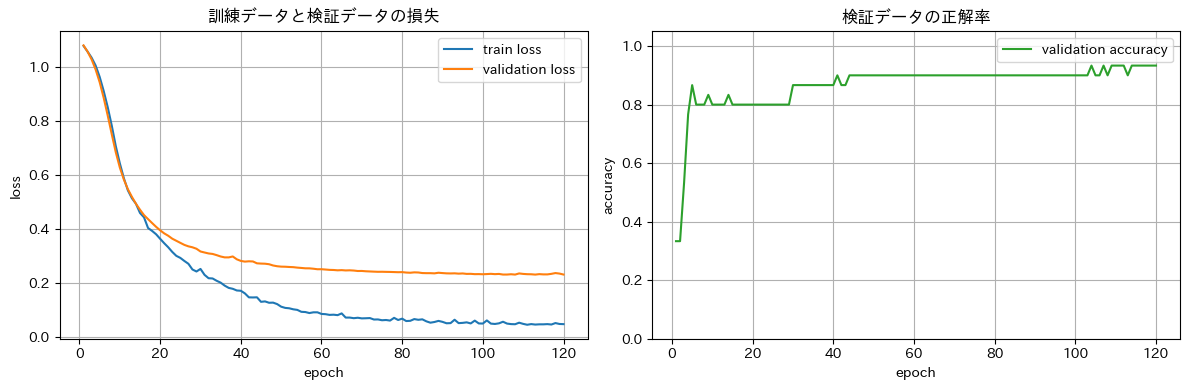

In [21]:
epochs = np.arange(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs, history["train_loss"], label="train loss")
axes[0].plot(epochs, history["val_loss"], label="validation loss")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].set_title("訓練データと検証データの損失")
axes[0].legend()

axes[1].plot(epochs, history["val_acc"], label="validation accuracy", color="tab:green")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("accuracy")
axes[1].set_title("検証データの正解率")
axes[1].set_ylim(0, 1.05)
axes[1].legend()
fig.tight_layout()
plt.show()


## 学習率を比較する

同じモデル構造でも，学習率を変えると学習の進み方が変わる。
次のセルでは，複数の学習率で学習し，損失の変化を比較する。

ここで使う `0.001`, `0.01`, `0.05`, `0.5` は，学習率の違いを見るための実験用の値である。
どの問題でもこの値がよい，という意味ではない。
損失がなかなか下がらないときは小さすぎる可能性があり，損失が大きく揺れるときは大きすぎる可能性がある。


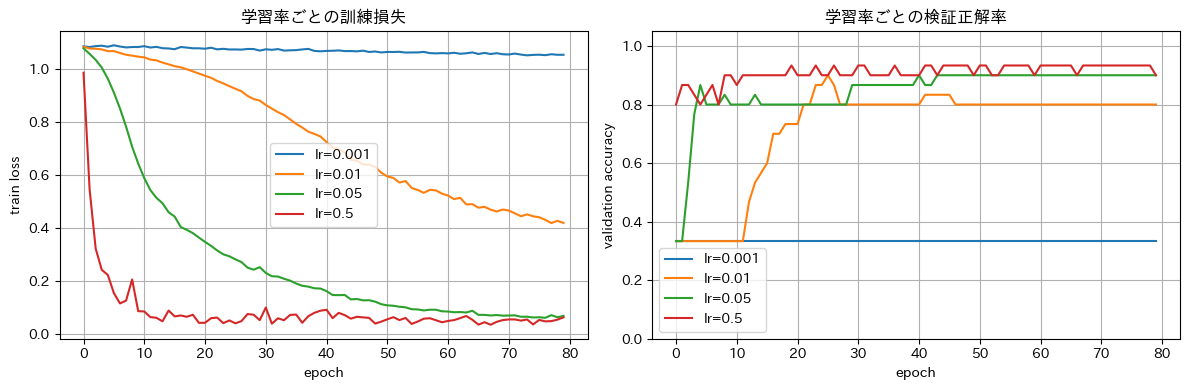

In [22]:
learning_rates = [0.001, 0.01, 0.05, 0.5]
lr_histories: dict[float, dict[str, list[float]]] = {}

for lr in learning_rates:
    torch.manual_seed(0)
    model_for_lr = make_iris_model()
    lr_histories[lr] = train_one_model(
        model_for_lr,
        train_loader,
        X_val_t,
        y_val_t,
        learning_rate=lr,
        epochs=80,
    )

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for lr, lr_history in lr_histories.items():
    axes[0].plot(lr_history["train_loss"], label=f"lr={lr}")
    axes[1].plot(lr_history["val_acc"], label=f"lr={lr}")

axes[0].set_xlabel("epoch")
axes[0].set_ylabel("train loss")
axes[0].set_title("学習率ごとの訓練損失")
axes[0].legend()
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("validation accuracy")
axes[1].set_title("学習率ごとの検証正解率")
axes[1].set_ylim(0, 1.05)
axes[1].legend()
fig.tight_layout()
plt.show()


## 汎化性能とは

汎化性能とは，学習に使っていない未知のデータに対する性能である．
授業中は，まず「訓練データでよく当たること」と「新しいデータでよく当たること」は別物だと押さえる．

訓練データだけに合わせすぎると，訓練データの accuracy は高いのに，validation/test の accuracy が低くなることがある．
これを過学習と呼ぶ．

ここでは，validation は学習中の確認や学習率の比較に使い，test は最後の一回の確認に使う．
`classification_report` には precision, recall, f1-score も出るが，最初は accuracy と混同行列を見ればよい．
```{note}
混同行列は，分類モデルの間違え方を確認するための表である．
このノートでは，行が正解クラス，列がモデルの予測クラスを表す．
例えば，正解が `versicolor` のデータをモデルが `virginica` と予測した場合，`versicolor` の行と `virginica` の列のマスに1つ数えられる．

対角線上のマスは「正解クラスと予測クラスが一致した数」である．
そのため，対角線上の数が多いほどよく分類できている．
一方，対角線から外れたマスは誤分類を表す．
どのマスが大きいかを見ると，モデルがどのクラス同士を混同しやすいかが分かる．
```


In [23]:
iris_model.eval()
with torch.no_grad():
    train_logits = iris_model(X_train_t)
    val_logits = iris_model(X_val_t)
    test_logits = iris_model(X_test_t)

print("train accuracy:", accuracy(train_logits, y_train_t))
print("validation accuracy:", accuracy(val_logits, y_val_t))
print("test accuracy:", accuracy(test_logits, y_test_t))

print(classification_report(
    y_test_t.numpy(),
    test_logits.argmax(dim=1).numpy(),
    target_names=iris.target_names,
))


train accuracy: 0.9777777791023254
validation accuracy: 0.9333333373069763
test accuracy: 0.9333333373069763
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



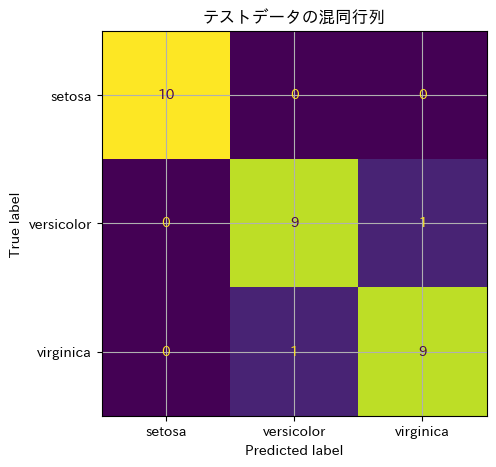

In [24]:
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test_t.numpy(),
    test_logits.argmax(dim=1).numpy(),
    display_labels=iris.target_names,
    ax=ax,
    colorbar=False,
)
ax.set_title("テストデータの混同行列")
plt.show()


## まとめ

このノートブックでは，ニューラルネットワークの学習を次の流れで確認した．

- `nn.Linear` は $xW^\top + b$ を計算し，入力の数値を別の数値へ変換する層である．
- 活性化関数を挟むことで，モデルは直線だけでは表せない関係を扱える．
- ニューラルネットワーク，活性化関数，損失関数は，基本的に微分可能な計算の組み合わせである．
- クロスエントロピーでは，正解クラスの確率が高いほど損失が小さくなる．PyTorch の `CrossEntropyLoss` には Softmax 前の logits を渡す．
- `loss.backward()` はバックプロパゲーションで勾配を計算し，`optimizer.step()` は勾配を使ってパラメータを更新する．
- train / validation / test を分けることで，学習，学習中の確認，最後の評価を分離できる．
- 汎化性能とは，学習に使っていないデータに対する性能である．